# Optuna Optimization Run

This notebook runs the optimization study using the standalone `model_opt.py` module.
It is configured to run multiple trials in parallel.

In [ ]:
import optuna
import model_opt  # Import the standalone module
import os
import numpy as np
import h5py
# Ensure the output directory exists
os.makedirs(r"D:\itay\ABM\Results\run", exist_ok=True)

def run_optimization(n_trials=200, n_jobs=10, show_progress_bar=False):
    """
    Run the Optuna optimization process using the standalone module.
    """
    local_storage = r"sqlite:///D:\itay\ABM\Results\run\opt_run.db"

    # Create a pruner to terminate unpromising trials early
    pruner = optuna.pruners.MedianPruner(n_startup_trials=10, n_warmup_steps=5)

    # Create a study object
    study = optuna.create_study(
        direction="minimize",
        storage=local_storage,
        study_name='opt_2_26_v1',
        load_if_exists=True,
        pruner=pruner,
        sampler=optuna.samplers.TPESampler()
    )

    # Run optimization
    # We pass the objective function from the module directly
    study.optimize(
        model_opt.objective,
        n_trials=n_trials,
        n_jobs=n_jobs,
        show_progress_bar=show_progress_bar
    )

    print("Best params:", study.best_params)
    print("Best value:", study.best_value)
    return study

# Run the optimization
if __name__ == "__main__":
    # 1. Load all data into RAM (Main Process only)
    print("Loading data into RAM...")
    ext_raster_data = np.load(model_opt.EXT_RASTER_PATH)[0:318, 0:280].astype(np.float64)
    place_raster_data = np.load(model_opt.PLACE_RASTER_PATH)[0:318, 0:280].astype(np.float64)

    perm_results = []
    if os.path.exists(model_opt.PERMANENT_DATA_PATH):
        with h5py.File(model_opt.PERMANENT_DATA_PATH, 'r') as f:
            metadata = f['metadata']
            num_groups = metadata.attrs['num_groups']
            arrays_per_group = metadata.attrs['arrays_per_group']
            # Load the last group as per original logic
            group = f[f'group_{num_groups}']
            perm_results = [np.array(group[f'array_{j}']).astype(np.float64) for j in range(arrays_per_group)]
    # 2. Upload to Shared Memory
    print("Moving data to Shared Memory...")
    shm_handles = []
    try:
        shm_handles.append(model_opt.SharedDataManager.create_shared_block("ext_raster", ext_raster_data))
        shm_handles.append(model_opt.SharedDataManager.create_shared_block("place_raster", place_raster_data))
        for i, arr in enumerate(perm_results):
            shm_handles.append(model_opt.SharedDataManager.create_shared_block(f"perm_res_{i}", arr))
        # 3. Run Optimization
        study = run_optimization(n_trials=13, n_jobs=4)
    finally:
        # 4. Cleanup Shared Memory
        for shm in shm_handles:
            shm.close()
            shm.unlink()
        print("Shared memory cleaned up.")


# Analysis and Visualization

The following cells analyze the results of the optimization study 'opt_2_26_v1'.

In [6]:
import optuna.visualization as vis
import pandas as pd

# 1. Load the study (Read-only mode is safer for analysis)
study_analysis = optuna.load_study(
    study_name='opt_2_26_v1',
    storage=r"sqlite:///D:\itay\ABM\Results\run\opt_run.db"
)

print(f"Number of finished trials: {len(study_analysis.trials)}")
print(f"Best trial value: {study_analysis.best_value}")
print("Best parameters:")
for key, value in study_analysis.best_params.items():
    print(f"  {key}: {value}")

# 2. Plot Optimization History (Check for convergence)
vis.plot_optimization_history(study_analysis).show()

# 3. Plot Hyperparameter Importances (See which params matter most)
# Note: Requires more than one parameter to be effective
vis.plot_param_importances(study_analysis).show()

# 4. Plot Slice (Visualize individual parameter distributions vs objective)
vis.plot_slice(study_analysis).show()


Number of finished trials: 218
Best trial value: 0.20125782351780996
Best parameters:
  dist_to_kb: 7
  p_water: 1
  Mean_rain: 3
  slope_suitability: 0
  return_to_site: 7
  humen_stress: 5
  Yearly_rain: 0


# Deep Dive: Best Trial Analysis

The following cell loads the raw agent-level data from the **best trial** found by Optuna.
It aggregates data across the multiple iterations (Monte Carlo runs) performed for that specific parameter set to visualize the model's dynamics and stability.

Deep diving into Best Trial: #173


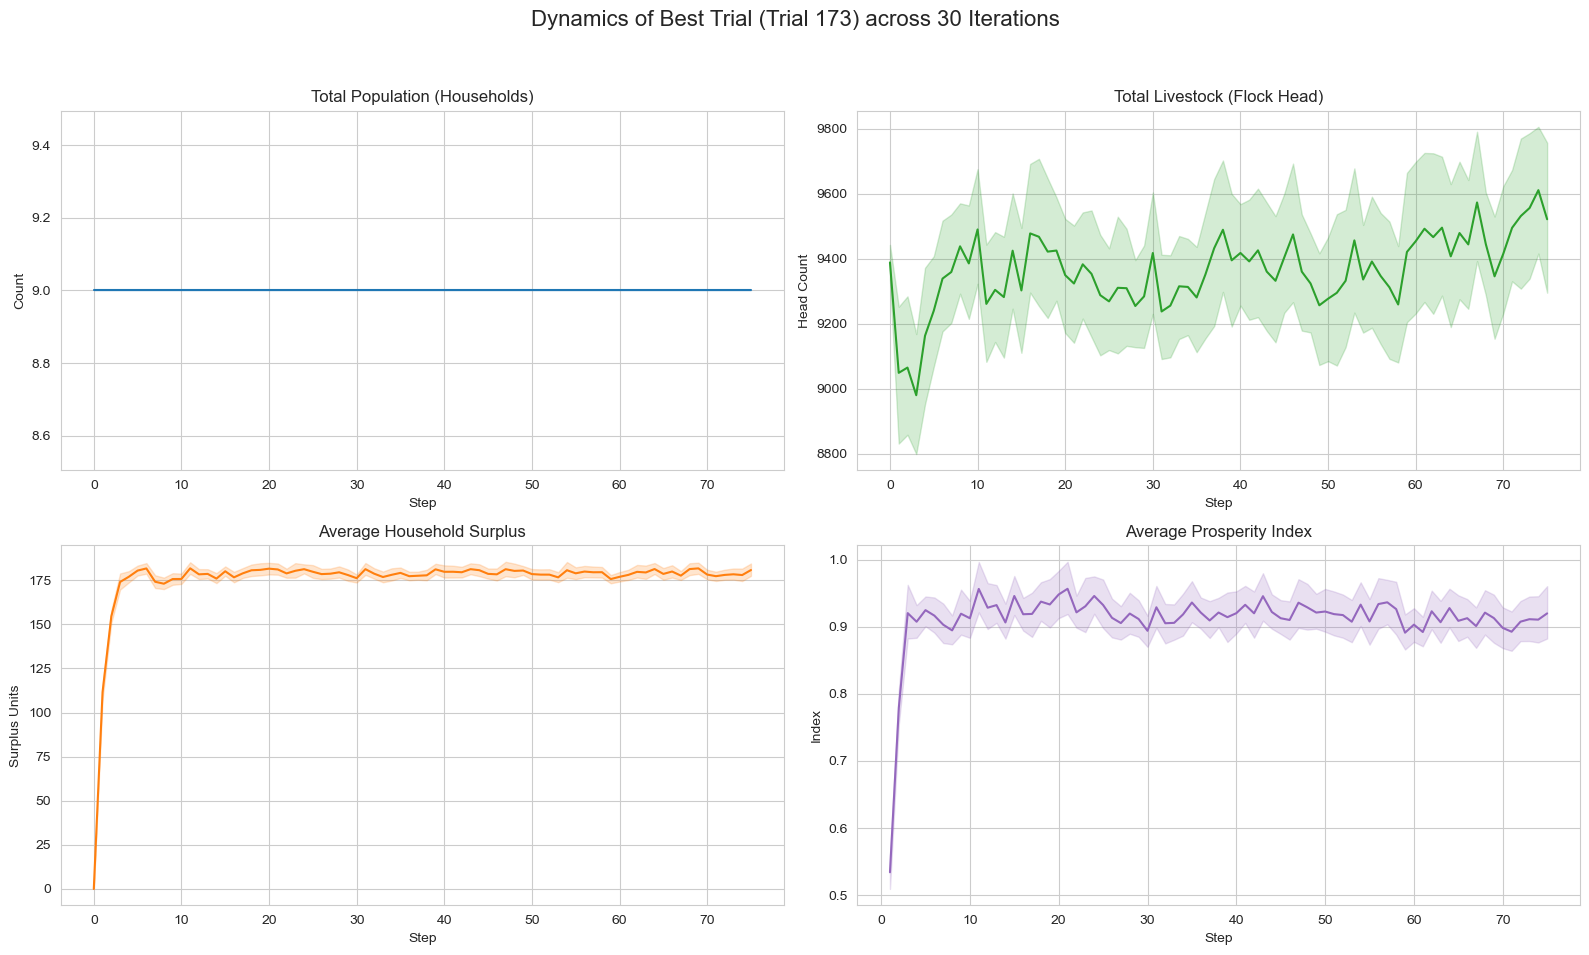

In [5]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Identify Best Trial
best_trial_num = study_analysis.best_trial.number
print(f"Deep diving into Best Trial: #{best_trial_num}")

# 2. Locate Data
base_dir = r"D:\itay\ABM\Results\run"
trial_path = (r"D:\itay\ABM\Results\trial_best_params")

data_frames = []

if os.path.exists(trial_path):
    # Iterate over iteration folders (iter_0, iter_1, ...)
    for folder_name in os.listdir(trial_path):
        if folder_name.startswith("iter_"):
            iter_num = folder_name.split("_")[1]
            csv_file = os.path.join(trial_path, folder_name, "household_data.csv")

            if os.path.exists(csv_file):
                df = pd.read_csv(csv_file)
                df['Iteration'] = iter_num
                data_frames.append(df)

if not data_frames:
    print(f"No data found in {trial_path}. Make sure the optimization ran and saved CSVs.")
else:
    # 3. Aggregate Data
    all_data = pd.concat(data_frames, ignore_index=True)

    # Group by Step and Iteration to get system-level stats per time step
    # We use 'Manpower' count as a proxy for Population (number of agents)
    system_stats = all_data.groupby(['Step', 'Iteration']).agg({
        'flocks': 'sum',
        'surplus': 'mean',
        'proseprity index': 'mean',
        'Manpower': ['sum', 'count']
    })

    # Flatten columns
    system_stats.columns = ['_'.join(col).strip() for col in system_stats.columns.values]
    system_stats = system_stats.reset_index()
    system_stats = system_stats.rename(columns={
        'flocks_sum': 'Total_Flocks',
        'surplus_mean': 'Avg_Surplus',
        'proseprity index_mean': 'Avg_Prosperity',
        'Manpower_sum': 'Total_Manpower',
        'Manpower_count': 'Population'
    })

    # 4. Visualization
    sns.set_style("whitegrid")
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle(f'Dynamics of Best Trial (Trial {best_trial_num}) across {len(data_frames)} Iterations', fontsize=16)

    # Plot A: Population
    # Seaborn lineplot automatically calculates and plots the confidence interval (shaded area)
    sns.lineplot(data=system_stats, x='Step', y='Population', ax=axes[0, 0], color='tab:blue')
    axes[0, 0].set_title('Total Population (Households)')
    axes[0, 0].set_ylabel('Count')

    # Plot B: Total Livestock
    sns.lineplot(data=system_stats, x='Step', y='Total_Flocks', ax=axes[0, 1], color='tab:green')
    axes[0, 1].set_title('Total Livestock (Flock Head)')
    axes[0, 1].set_ylabel('Head Count')

    # Plot C: Average Surplus
    sns.lineplot(data=system_stats, x='Step', y='Avg_Surplus', ax=axes[1, 0], color='tab:orange')
    axes[1, 0].set_title('Average Household Surplus')
    axes[1, 0].set_ylabel('Surplus Units')

    # Plot D: Prosperity Index
    sns.lineplot(data=system_stats, x='Step', y='Avg_Prosperity', ax=axes[1, 1], color='tab:purple')
    axes[1, 1].set_title('Average Prosperity Index')
    axes[1, 1].set_ylabel('Index')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

In [ ]:
 # Run Best Trial with Plotting
 #
 # The following cell runs 30 iterations using the best parameters found.
 # It enables map plotting (`plot=True`) and saves results to `Results/trial_best_params`.

 import model_opt
 import numpy as np
 import os

 # 1. Prepare Parameters
 best_params = study_analysis.best_params
 sum_w = sum(best_params.values())
 norm_params = {k: v / sum_w for k, v in best_params.items()}

 permanent_weights_dict = {
     "dist_to_kb": norm_params["dist_to_kb"],
     "p_water": norm_params["p_water"],
     "Mean_rain": norm_params["Mean_rain"],
     "slope_suitability": norm_params["slope_suitability"],
 }

 yearly_weights_dict = {
     "return_to_site": norm_params["return_to_site"],
     "humen_stress": norm_params["humen_stress"],
     "Yearly_rain": norm_params["Yearly_rain"],
 }

 ras_wts = list(permanent_weights_dict.values()) + list(yearly_weights_dict.values())

 # 2. Run Settings
 n_iterations = 30
 n_years = 75
 output_base_dir = r"D:\itay\ABM\Results"
 trial_name = "best_params"

 print(f"Running {n_iterations} iterations for trial '{trial_name}' with plotting enabled...")
 model_opt.ensure_data_loaded()

 for i in range(n_iterations):
     print(f"  Iteration {i}...")
     seed = (study_analysis.best_trial.number * 100) + i
     model_opt.run_model_opt(
         model_years=n_years,
         ras_wts=ras_wts,
         main_run_directory=output_base_dir,
         trial_number=trial_name,
         iteration=i,
         permanent_weights_dict=permanent_weights_dict,
         yearly_weights_dict=yearly_weights_dict,
         seed=seed,
         plot=True
     )
 print(f"Completed. Results in {os.path.join(output_base_dir, 'trial_' + trial_name)}")


# Quantitative Summary
#
# This cell generates statistical summaries for:
# 1. The Optimization Process (Parameter importance, trial statistics).
# 2. The Best Trial's 30 Iterations (Mean/Std of key metrics across runs).

In [7]:
import pandas as pd
import numpy as np
import os

# --- Part 1: Optimization Summary ---
print("--- Optimization Summary ---")
df_trials = study_analysis.trials_dataframe()
print(f"Total Trials: {len(df_trials)}")
print(f"Completed Trials: {len(df_trials[df_trials['state'] == 'COMPLETE'])}")
print(f"Pruned Trials: {len(df_trials[df_trials['state'] == 'PRUNED'])}")

best_val = study_analysis.best_value
print(f"Best Objective Value (Error): {best_val:.4f}")

print("\nBest Parameters:")
for k, v in study_analysis.best_params.items():
    print(f"  {k}: {v}")

# Save optimization summary
opt_summary_path = r"D:\itay\ABM\Results\run\optimization_summary.csv"
df_trials.to_csv(opt_summary_path)
print(f"\nFull optimization history saved to: {opt_summary_path}")


# --- Part 2: Best Trial (30 Iterations) Summary ---
print("\n--- Best Trial (30 Iterations) Quantitative Analysis ---")
results_dir = r"D:\itay\ABM\Results\trial_best_params"
summary_data = []

if os.path.exists(results_dir):
    for folder_name in os.listdir(results_dir):
        if folder_name.startswith("iter_"):
            iter_num = int(folder_name.split("_")[1])
            csv_file = os.path.join(results_dir, folder_name, "household_data.csv")
            
            if os.path.exists(csv_file):
                df = pd.read_csv(csv_file)
                
                # Calculate metrics for this specific iteration
                # We look at the End-state metrics (Last Year/Step)
                last_step = df['Step'].max()
                end_state = df[df['Step'] == last_step]
                
                summary_data.append({
                    'Iteration': iter_num,
                    'Final_Households': len(end_state),
                    'Final_Total_Manpower': end_state['Manpower'].sum(),
                    'Final_Total_Flocks': end_state['flocks'].sum(),
                    'Final_Avg_Surplus': end_state['surplus'].mean(),
                    'Final_Avg_Prosperity': end_state['proseprity index'].mean(),
                })

    if summary_data:
        df_summary = pd.DataFrame(summary_data)
        stats = df_summary.describe().transpose()[['mean', 'std', 'min', 'max']]
        print("\nSummary Statistics across 30 Iterations (Final Year):")
        print(stats)
        
        stats.to_csv(os.path.join(results_dir, "best_params_30iter_stats.csv"))
        print(f"\nAggregated statistics saved to: {os.path.join(results_dir, 'best_params_30iter_stats.csv')}")
    else:
        print("No iteration data found.")
else:
    print(f"Directory not found: {results_dir}")

--- Optimization Summary ---
Total Trials: 218
Completed Trials: 143
Pruned Trials: 57
Best Objective Value (Error): 0.2013

Best Parameters:
  dist_to_kb: 7
  p_water: 1
  Mean_rain: 3
  slope_suitability: 0
  return_to_site: 7
  humen_stress: 5
  Yearly_rain: 0

Full optimization history saved to: D:\itay\ABM\Results\run\optimization_summary.csv

--- Best Trial (30 Iterations) Quantitative Analysis ---

Summary Statistics across 30 Iterations (Final Year):
                             mean         std          min           max
Iteration               14.500000    8.803408     0.000000     29.000000
Final_Households         9.000000    0.000000     9.000000      9.000000
Final_Total_Manpower   523.000000   36.221541   469.000000    635.000000
Final_Total_Flocks    9521.917454  647.361976  8426.012317  11120.285762
Final_Avg_Surplus      180.738897    9.838987   167.837974    200.697928
Final_Avg_Prosperity     0.920072    0.108122     0.761616      1.217911

Aggregated statistics sav